<a href="https://colab.research.google.com/github/VanshRana1232/house-price-prediction/blob/main/housing_ml_corrected.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sklearn
from pathlib import Path
import tarfile
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from zlib import crc32
from sklearn.model_selection import train_test_split
from pandas.plotting import scatter_matrix
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error

In [ ]:
# Custom Transformer
class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

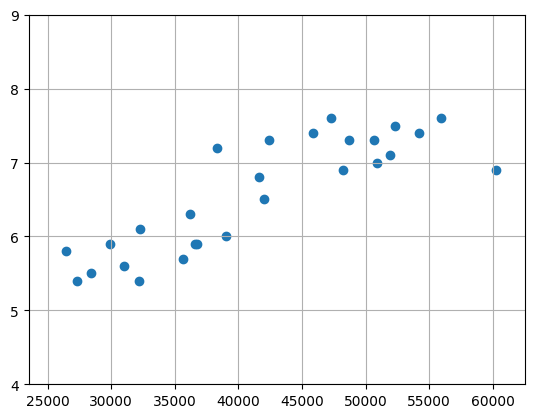

Predicted life satisfaction for Puerto Rico: [[6.01610329]]


In [ ]:
# Life Satisfaction Example
data_root = "https://github.com/ageron/data/raw/main/"
lifesat = pd.read_csv(data_root + "lifesat/lifesat.csv")

X_lifesat = lifesat[["GDP per capita (USD)"]].values
y_lifesat = lifesat[["Life satisfaction"]].values

plt.scatter(X_lifesat, y_lifesat)
plt.grid(True)
plt.axis([23_500, 62_500, 4, 9])
plt.show()

model_lifesat = LinearRegression()
model_lifesat.fit(X_lifesat, y_lifesat)

X_new = [[33_442.8]]
y_new = model_lifesat.predict(X_new)
print("Predicted life satisfaction for Puerto Rico:", y_new)

In [ ]:
# Load Housing Data
def load_housing_data():
    path = Path("Datasets/housing.tgz")
    if not path.is_file():
        Path("Datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, path)
        with tarfile.open(path) as housing_path:
            housing_path.extractall(path="Datasets")
    return pd.read_csv(Path("Datasets/housing/housing.csv"))

housing = load_housing_data()
housing.head()

/tmp/ipykernel_1101/3565441823.py:9: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_path.extractall(path="Datasets")


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
housing.info()
print(housing["ocean_proximity"].value_counts())
housing.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


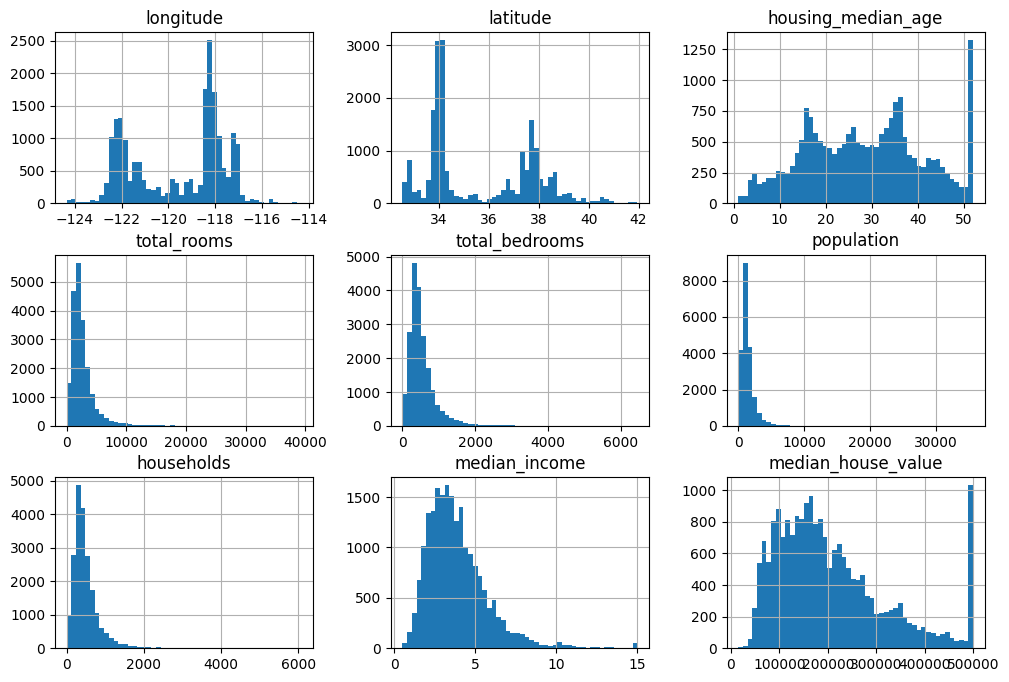

In [ ]:
housing.hist(bins=50, figsize=(12, 8))
plt.show()

In [ ]:
# Manual shuffle and split
def shuffle_and_split(data, test_ratio, rng):
    shuffle_indices = rng.permutation(len(data))
    test_split = int(len(data) * test_ratio)
    train_set = shuffle_indices[:test_split]
    test_set = shuffle_indices[test_split:]
    return data.iloc[train_set], data.iloc[test_set]

rng = np.random.default_rng()
train_set_manual, test_set_manual = shuffle_and_split(housing, 0.2, rng)
print("Manual Train:", len(train_set_manual), "Test:", len(test_set_manual))

Manual Train: 4128 Test: 16512


In [ ]:
# Stable test set via CRC32
def is_id_in_the_test_set(identifier, test_ratio):
    return crc32(np.int64(identifier)) < 2**32 * test_ratio

def split_data(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: is_id_in_the_test_set(id_, test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]

housing_with_id = housing.copy()
housing_with_id["id"] = housing["longitude"] * 1000 + housing["latitude"]
train_set, test_set = split_data(housing_with_id, 0.2, "id")
print(f"Train size: {len(train_set)}, Test size: {len(test_set)}")

Train size: 16322, Test size: 4318


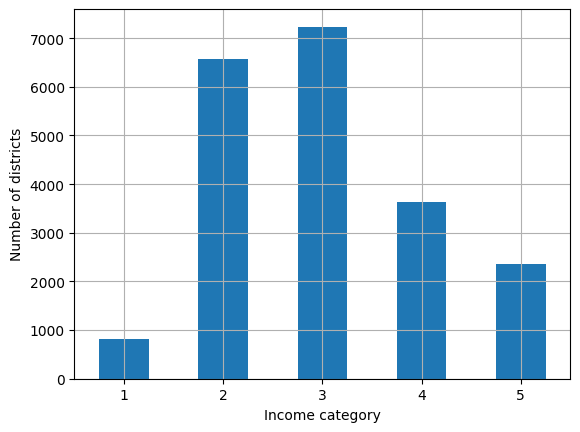

In [ ]:
# Stratified Sampling
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

housing["income_cat"] = pd.cut(
    housing["median_income"],
    bins=[0, 1.5, 3, 4.5, 6, np.inf],
    labels=[1, 2, 3, 4, 5]
)

cat_count = housing["income_cat"].value_counts().sort_index()
cat_count.plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
plt.show()

strat_train_set, strat_test_set = train_test_split(
    housing, test_size=0.2, stratify=housing["income_cat"], random_state=42
)

for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

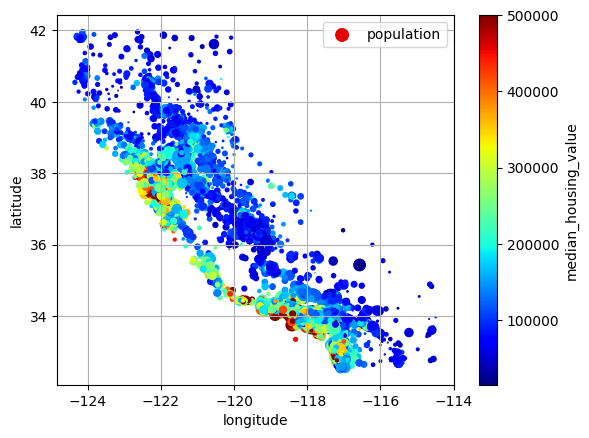

In [ ]:
# Explore and Visualize
housing_train = strat_train_set.drop("median_house_value", axis=1).copy()
housing_labels = strat_train_set["median_house_value"].copy()

lon = housing_train["longitude"]
lat = housing_train["latitude"]

scatter = plt.scatter(lon, lat, s=housing_train["population"] / 100,
                      cmap="jet", c=housing_labels, label="population")
plt.grid(True)
plt.legend()
plt.colorbar(scatter, label="median_housing_value")
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.show()

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64


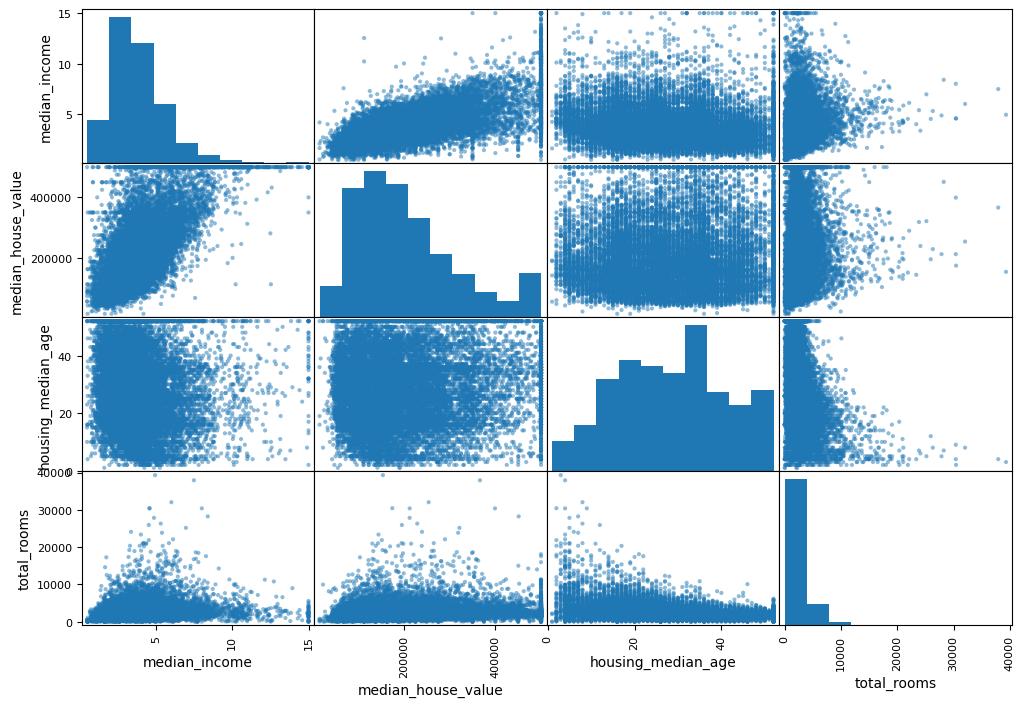

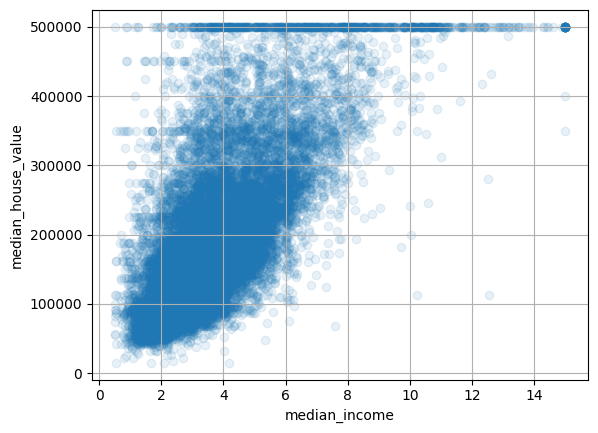

In [ ]:
# Correlations
cor_coeff = strat_train_set.corr(numeric_only=True)
print(cor_coeff["median_house_value"].sort_values(ascending=False))

attributes = ["median_income", "median_house_value", "housing_median_age", "total_rooms"]
scatter_matrix(strat_train_set[attributes], figsize=(12, 8))
plt.show()

plt.scatter(x=housing_train["median_income"], y=housing_labels, alpha=0.1)
plt.grid(True)
plt.xlabel("median_income")
plt.ylabel("median_house_value")
plt.show()

In [ ]:
# Feature Engineering
housing_train["rooms_per_house"] = housing_train["total_rooms"] / housing_train["households"]
housing_train["bedrooms_ratio"] = housing_train["total_bedrooms"] / housing_train["total_rooms"]
housing_train["people_per_house"] = housing_train["population"] / housing_train["households"]

housing_train_with_labels = housing_train.copy()
housing_train_with_labels["median_house_value"] = housing_labels

corr_matrix = housing_train_with_labels.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.688380
rooms_per_house,0.143663
total_rooms,0.137455
housing_median_age,0.102175
households,0.071426
total_bedrooms,0.054635
population,-0.020153
people_per_house,-0.038224
longitude,-0.050859


In [ ]:
# Preprocessing
housing_num = housing_train.select_dtypes(include=[np.number])

imputer = SimpleImputer(strategy="median")
imputer.fit(housing_num)
X_imputed = imputer.transform(housing_num)

housing_tr = pd.DataFrame(X_imputed, columns=housing_num.columns, index=housing_num.index)

housing_cat = housing_train[["ocean_proximity"]]

ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)

cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

std_scaled = StandardScaler()
housing_num_std_scaled = std_scaled.fit_transform(housing_num)

age_simil_35 = rbf_kernel(housing_num[["housing_median_age"]], [[35]], gamma=0.1)

In [ ]:
# TransformedTargetRegressor
some_new_data = housing_train[["median_income"]].iloc[:5]
model_ttr = TransformedTargetRegressor(LinearRegression(), transformer=StandardScaler())
model_ttr.fit(housing_train[["median_income"]], housing_labels)
predictions_ttr = model_ttr.predict(some_new_data)
print(predictions_ttr)

log_transformer = FunctionTransformer(np.log, inverse_func=np.exp)
log_pop = log_transformer.transform(housing_train[["population"]])

rbf_transformer = FunctionTransformer(rbf_kernel, kw_args=dict(Y=[[35.]], gamma=0.1))
age_simil_35 = rbf_transformer.transform(housing_train[["housing_median_age"]])

sf_coords = 37.7749, -122.41
sf_transformer = FunctionTransformer(rbf_kernel, kw_args=dict(Y=[sf_coords], gamma=0.1))
sf_simil = sf_transformer.transform(housing_train[["latitude", "longitude"]])

[131997.15275877 299359.35844434 146023.37185694 138840.33653057
 192016.61557639]


In [ ]:
# Pipelines
num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

sklearn.set_config(display="diagram")

housing_num_prepared = num_pipeline.fit_transform(housing_num)
df_housing_num_prepared = pd.DataFrame(
    housing_num_prepared,
    columns=num_pipeline.get_feature_names_out(),
    index=housing_num.index
)

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore")
)

preprocessing = make_column_transformer(
    (num_pipeline, make_column_selector(dtype_include=np.number)),
    (cat_pipeline, make_column_selector(dtype_include=object)),
)

housing_prepared = preprocessing.fit_transform(housing_train)

In [ ]:
# Full Preprocessing Pipeline
def column_ratio(X):
    return X[:, [0]] / X[:, [1]]

def ratio_name(function_transformer, feature_names_in):
    return ["ratio"]

def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        StandardScaler()
    )

log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log, feature_names_out="one-to-one"),
    StandardScaler()
)

cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)
default_num_pipeline = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())

preprocessing = ColumnTransformer([
    ("bedrooms", ratio_pipeline(), ["total_bedrooms", "total_rooms"]),
    ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]),
    ("people_per_house", ratio_pipeline(), ["population", "households"]),
    ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population", "households", "median_income"]),
    ("geo", cluster_simil, ["latitude", "longitude"]),
    ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
],
    remainder=default_num_pipeline
)

In [ ]:
# Train and Evaluate
lin_reg = make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(housing_train, housing_labels)

housing_predictions = lin_reg.predict(housing_train)

print("First 5 predictions:", housing_predictions[:5].round(-2))
print("First 5 actual:     ", housing_labels.iloc[:5].values)

rmse = root_mean_squared_error(housing_labels, housing_predictions)
print(f"Training RMSE: {rmse:,.0f}")



First 5 predictions: [255700. 369200. 131900.  87300. 329600.]
First 5 actual:      [458300. 483800. 101700.  96100. 361800.]
Training RMSE: 68,061


In [ ]:
#DecisionTree Model
from sklearn.tree import DecisionTreeRegressor
tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state=42))
tree_reg.fit(housing_train, housing_labels)
housing_predictions = tree_reg.predict(housing_train)
tree_rmse = root_mean_squared_error(housing_labels,housing_predictions)
print(tree_rmse)

0.0


In [ ]:
#Cross-validation to check if decision tree is overfitting
from sklearn.model_selection import cross_val_score
tree_rmses = -cross_val_score(tree_reg,housing_train,housing_labels,scoring="neg_root_mean_squared_error",cv=10)
pd.Series(tree_rmses).describe()

,0
count,10.000000
mean,66998.428614
std,1266.996780
min,65461.094759
25%,66111.271037
50%,66668.294149
75%,67997.650087
max,69310.614259


In [ ]:
#RandomForest model
from sklearn.ensemble import RandomForestRegressor
forest_reg = make_pipeline(preprocessing,RandomForestRegressor(n_estimators=10,random_state=42))
forest_rmses = -cross_val_score(forest_reg,housing_train,housing_labels,scoring="neg_root_mean_squared_error",cv=3)
pd.Series(forest_rmses).describe()

,0
count,3.000000
mean,49978.541663
std,564.652278
min,49339.017080
25%,49763.686827
50%,50188.356573
75%,50298.303954
max,50408.251335


In [ ]:
#Fine-tuning the model
from sklearn.model_selection import GridSearchCV
full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("random_forest", RandomForestRegressor(random_state=42)),
])
param_grid = [
   {"preprocessing__geo__n_clusters":[5,8,10],
    "random_forest__max_features":[4,6,8]},
   {"preprocessing__geo__n_clusters":[10,15],
    "random_forest__max_features":[6,8,10]},
]
grid_search = GridSearchCV(full_pipeline,param_grid,cv=3,scoring="neg_root_mean_squared_error")
grid_search.fit(housing_train,housing_labels)
grid_search.best_params_
#we aint use best estimator as wec can analyse every combination with cv results
cv_res = pd.DataFrame(grid_search.cv_results_)#convert results into dataframe.
cv_res.sort_values(by="mean_test_score",ascending=False,inplace=True)#inplace is to keep it in same dataframe and as rmse is -ve, it's descending
[...] #change column name to fit on this page
cv_res.head()#to show first few rows

{'preprocessing__geo__n_clusters': 15, 'random_forest__max_features': 6}

In [ ]:
#Random search vs grid search: for few hyperparamerters grid search is best as it tries every possible combination
#but random search do limited combinations as per you defined it and used when large no of hyperparameters.
#Every model has specific hyperparameter which can be get by .get_params()
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
param_distribs = {"preprocessing_geo_n_clusters":randint(low=3,high=50)
                 "random_forest_max_features":randint(low=2,high=20)}
rnd_search = RandomizedSearchCV(
    full_pipeline, param_distributions = param_distribs, n_iters=10,cv=3,
    scoring = "neg_root_mean_squared_error",random_state=42)
rnd_search.fit(housing_train,housing_labels)

